# Unit 2 — Linear models for regression

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`). Run the first cell before the others.

In [1]:
%config InlineBackend.figure_format = "svg"
import os
import sys
sys.path.insert(0, "website")          # plot style lives in website/weather.py
from weather import use_style
use_style()
if os.path.basename(os.getcwd()) != "website":
    os.chdir("website")                # so the programs find data/seattle_weather.csv

## Practice 1 — Implement linear regression to perform prediction

Predict tomorrow's highest temperature from today's weather. Linear regression learns one weight per input column: prediction = intercept + w1·x1 + w2·x2 + … We train on 80% of the days and test on the other 20%.

Intercept: 2.29
Weight of temp_max : 0.77
Weight of temp_min : 0.22
Weight of precipitation : -0.05
Weight of wind : -0.06

Mean absolute error: 2.26 °C
R² score: 0.87 (1 = perfect)

   actual  predicted
0    21.7       23.0
1     9.4        9.4
2     7.8       10.3
3    21.7       25.5
4    13.9       13.9
5    23.3       21.4
6    21.1       27.5
7    16.7       14.5
8    14.4       14.9
9    24.4       23.7


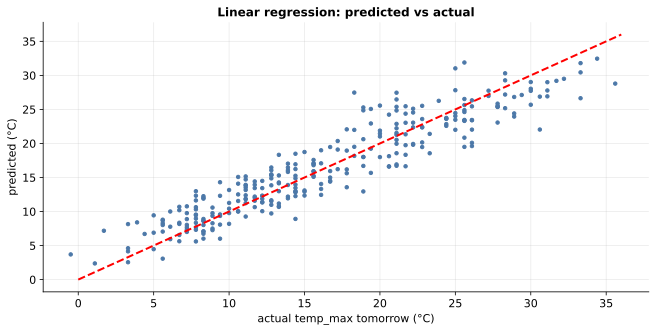

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("data/seattle_weather.csv")

# Target: tomorrow's temp_max. shift(-1) moves every value up one row.
df["temp_max_tomorrow"] = df["temp_max"].shift(-1)
df = df.dropna()   # the last day has no tomorrow

# Inputs (X) and output (y)
X = df[["temp_max", "temp_min", "precipitation", "wind"]]
y = df["temp_max_tomorrow"]

# 80% of the days to train, 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model and predict
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# The learned equation
print("Intercept:", round(model.intercept_, 2))
for column, weight in zip(X.columns, model.coef_):
    print("Weight of", column, ":", round(weight, 2))
print()

# How good the predictions are
print("Mean absolute error:", round(mean_absolute_error(y_test, y_pred), 2), "°C")
print("R² score:", round(r2_score(y_test, y_pred), 2), "(1 = perfect)")
print()

# A few predictions next to the real values
result = pd.DataFrame({"actual": y_test.values, "predicted": y_pred.round(1)})
print(result.head(10))

# Plot: predicted against actual (perfect predictions lie on the red line)
plt.figure(figsize=(9, 4.5))
plt.scatter(y_test, y_pred, s=12)
plt.plot([0, 36], [0, 36], color="red", linestyle="--")
plt.xlabel("actual temp_max tomorrow (°C)")
plt.ylabel("predicted (°C)")
plt.title("Linear regression: predicted vs actual")
plt.show()

## Practice 2 — Implement Bayesian logistic regression and SVM for classification

Will it rain tomorrow (1) or not (0)? Bayesian logistic regression starts with a prior belief that every weight is near 0, learns the most probable weights from the data, and also tells how sure it is about each weight. An SVM draws the boundary between the two classes with the widest possible margin.

Bayesian logistic regression accuracy: 0.726
               weight  ± 2 std
temp_max       -1.308    0.309
temp_min        0.690    0.282
precipitation   0.656    0.204
wind           -0.038    0.136

P(rain tomorrow) for 5 test days: [0.17 0.78 0.52 0.13 0.49]

SVM (linear kernel) accuracy: 0.692
SVM (RBF kernel) accuracy:    0.729


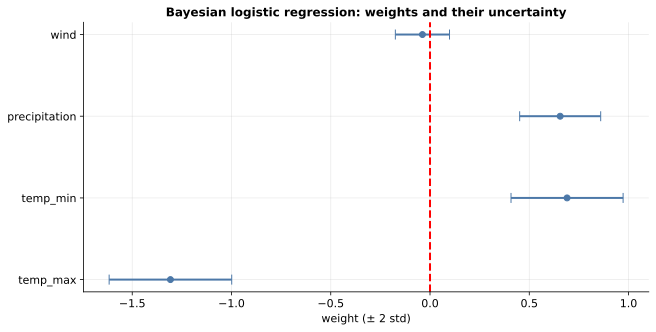

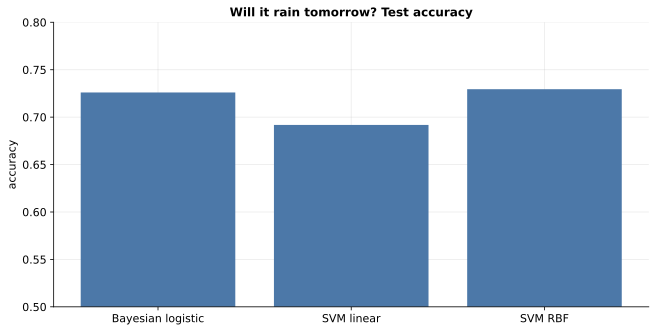

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df = pd.read_csv("data/seattle_weather.csv")

# Target: 1 if it rains tomorrow, else 0
df["precipitation_tomorrow"] = df["precipitation"].shift(-1)
df["rain_tomorrow"] = (df["precipitation_tomorrow"] > 0).astype(int)
df = df.dropna()   # the last day has no tomorrow

columns = ["temp_max", "temp_min", "precipitation", "wind"]
X = df[columns]
y = df["rain_tomorrow"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Put every column on the same scale (mean 0, std 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 1. Bayesian logistic regression
# The prior: every weight is near 0 (a Gaussian). In scikit-learn this prior is
# the L2 penalty and C is its width. fit() finds the most probable weights.
blr = LogisticRegression(C=1.0)
blr.fit(X_train, y_train)
blr_acc = accuracy_score(y_test, blr.predict(X_test))
print("Bayesian logistic regression accuracy:", round(blr_acc, 3))

# How sure are we about each weight? (Laplace approximation)
# covariance = inverse of (Xᵀ · W · X + I/C), where W holds p(1 - p) for each day
# and I/C comes from the prior (here C = 1, so it is just I)
p = blr.predict_proba(X_train)[:, 1]
W = np.diag(p * (1 - p))
H = X_train.T @ W @ X_train + np.eye(len(columns))
covariance = np.linalg.inv(H)
std = np.sqrt(np.diag(covariance))

weights = pd.DataFrame({"weight": blr.coef_[0], "± 2 std": 2 * std}, index=columns)
print(weights.round(3))
print()

# Probability of rain tomorrow for the first 5 test days
print("P(rain tomorrow) for 5 test days:", blr.predict_proba(X_test[:5])[:, 1].round(2))
print()

# 2. Support vector machines
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train, y_train)
linear_acc = accuracy_score(y_test, svm_linear.predict(X_test))
print("SVM (linear kernel) accuracy:", round(linear_acc, 3))

svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train, y_train)
rbf_acc = accuracy_score(y_test, svm_rbf.predict(X_test))
print("SVM (RBF kernel) accuracy:   ", round(rbf_acc, 3))

# Plot 1: each weight with its uncertainty
plt.figure(figsize=(9, 4.5))
plt.errorbar(blr.coef_[0], columns, xerr=2 * std, fmt="o", capsize=5)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("weight (± 2 std)")
plt.title("Bayesian logistic regression: weights and their uncertainty")
plt.show()

# Plot 2: compare the accuracies
plt.figure(figsize=(9, 4.5))
plt.bar(["Bayesian logistic", "SVM linear", "SVM RBF"], [blr_acc, linear_acc, rbf_acc])
plt.ylim(0.5, 0.8)
plt.ylabel("accuracy")
plt.title("Will it rain tomorrow? Test accuracy")
plt.show()